/tmp/ipykernel_210/402043628.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


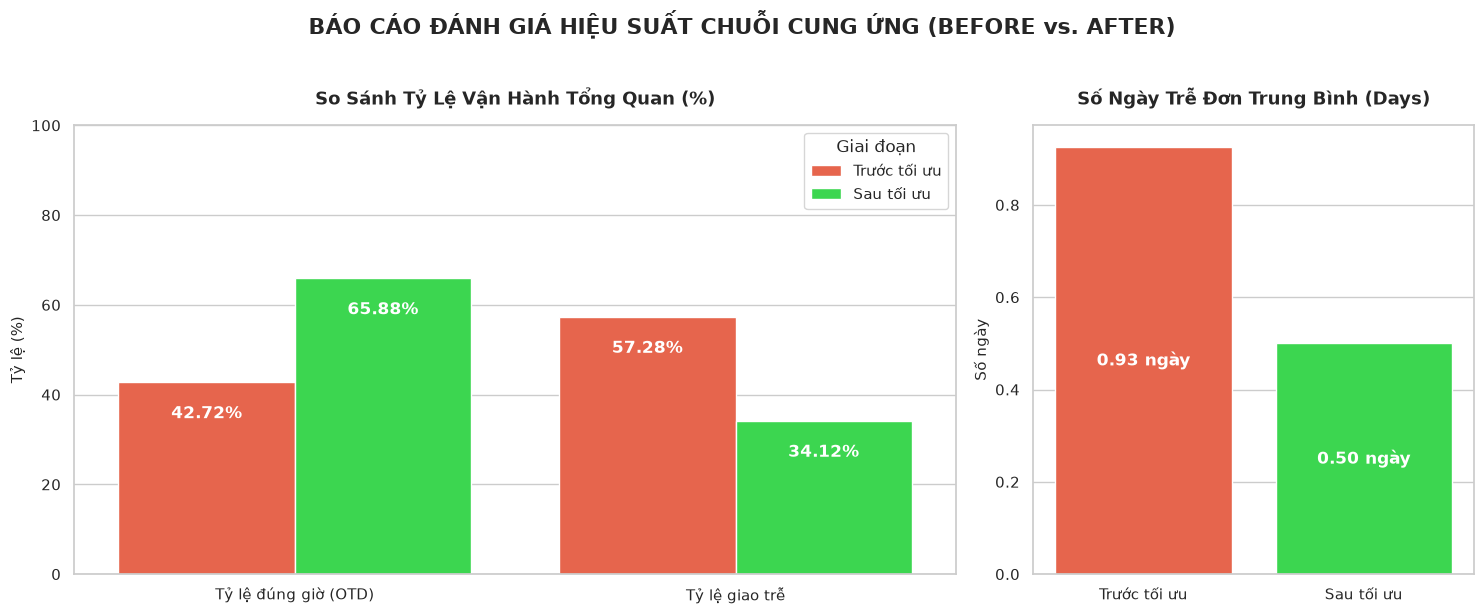

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. ĐỌC VÀ CHUẨN BỊ DỮ LIỆU
df_orig = pd.read_csv("data/processed/supply_chain_processed.csv")
df_opt = pd.read_csv("data/processed/optimized.csv")

# Tính toán các chỉ số cho tập dữ liệu Gốc (Before)
df_orig["Delay_Days"] = np.where(
    (val := (df_orig.actual_lead_time - df_orig.scheduled_lead_time)) < 0, 0, val
)
df_orig["is_late_calculated"] = np.where(
    (df_orig["scheduled_lead_time"] - df_orig["actual_lead_time"]) >= 0, 0, 1
)

before_otd = (1 - df_orig["is_late_calculated"].mean()) * 100
before_late = df_orig["is_late_calculated"].mean() * 100
before_delay = df_orig["Delay_Days"].mean()

# Tính toán các chỉ số cho tập dữ liệu Tối ưu (After)
after_otd = (1 - df_opt["is_late"].mean()) * 100
after_late = df_opt["is_late"].mean() * 100
after_delay = df_opt["Delay_Days"].mean()

# Tạo DataFrame phục vụ vẽ biểu đồ
df_kpi_rates = pd.DataFrame(
    {
        "Giai đoạn": ["Trước tối ưu", "Sau tối ưu", "Trước tối ưu", "Sau tối ưu"],
        "Chỉ số": [
            "Tỷ lệ đúng giờ (OTD)",
            "Tỷ lệ đúng giờ (OTD)",
            "Tỷ lệ giao trễ",
            "Tỷ lệ giao trễ",
        ],
        "Giá trị (%)": [before_otd, after_otd, before_late, after_late],
    }
)

df_kpi_days = pd.DataFrame(
    {
        "Giai đoạn": ["Trước tối ưu", "Sau tối ưu"],
        "Số ngày trễ TB": [before_delay, after_delay],
    }
)

# 2. THIẾT KẾ GIAO DIỆN BIỂU ĐỒ
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [2, 1]})

# --- SUBPLOT 1: SO SÁNH TỶ LỆ DỰA TRÊN % ---
sns.barplot(
    data=df_kpi_rates,
    x="Chỉ số",
    y="Giá trị (%)",
    hue="Giai đoạn",
    ax=axes[0],
    palette=["#ff5334", "#22f03d"],
)
axes[0].set_title(
    "So Sánh Tỷ Lệ Vận Hành Tổng Quan (%)", fontsize=13, weight="bold", pad=15
)
axes[0].set_ylabel("Tỷ lệ (%)", fontsize=11)
axes[0].set_xlabel("")
axes[0].set_ylim(0, 100)

# Thêm Data Labels hiển thị số liệu trực tiếp trên cột %
for p in axes[0].patches:
    if p.get_height() > 0:
        axes[0].annotate(
            f"{p.get_height():.2f}%",
            (p.get_x() + p.get_width() / 2.0, p.get_height() - 7),
            ha="center",
            va="center",
            color="white",
            weight="bold",
            xytext=(0, 0),
            textcoords="offset points",
        )

# --- SUBPLOT 2: SO SÁNH SỐ NGÀY TRỄ TRUNG BÌNH ---
sns.barplot(
    data=df_kpi_days,
    x="Giai đoạn",
    y="Số ngày trễ TB",
    ax=axes[1],
    palette=["#ff5334", "#22f03d"],
)
axes[1].set_title(
    "Số Ngày Trễ Đơn Trung Bình (Days)", fontsize=13, weight="bold", pad=15
)
axes[1].set_ylabel("Số ngày", fontsize=11)
axes[1].set_xlabel("")

# Thêm Data Labels cho cột số ngày
for p in axes[1].patches:
    axes[1].annotate(
        f"{p.get_height():.2f} ngày",
        (p.get_x() + p.get_width() / 2.0, p.get_height() / 2.0),
        ha="center",
        va="center",
        color="white",
        weight="bold",
        xytext=(0, 0),
        textcoords="offset points",
    )

plt.suptitle(
    "BÁO CÁO ĐÁNH GIÁ HIỆU SUẤT CHUỖI CUNG ỨNG (BEFORE vs. AFTER)",
    fontsize=16,
    weight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. ĐỌC VÀ LỌC DỮ LIỆU ĐƠN HỦY
df_orig = pd.read_csv("data/processed/supply_chain_processed.csv")

# Lọc các đơn hàng bị hủy
df_cancelled = df_orig[df_orig["Delivery Status"] == "Shipping canceled"].copy()

# Xác định trạng thái trễ đơn tại thời điểm hủy
df_cancelled["Trạng thái đơn"] = np.where(
    (df_cancelled["scheduled_lead_time"] - df_cancelled["actual_lead_time"]) >= 0,
    "Đúng giờ / Sớm",
    "Giao hàng trễ (Late)",
)

# Tạo bảng chéo (Crosstab) tính tỷ lệ phần trăm 100% theo từng Phương thức vận chuyển
cancel_matrix = pd.crosstab(
    df_cancelled["Shipping Mode"],
    df_cancelled["Trạng thái đơn"],
    normalize="index",
) * 100

# Sắp xếp lại thứ tự cột để đưa lý do "Giao hàng trễ" ra trước làm điểm nhấn thị giác
cancel_matrix = cancel_matrix[["Giao hàng trễ (Late)", "Đúng giờ / Sớm"]]

# 2. THIẾT KẾ BIỂU ĐỒ CỘT CHỒNG 100% (NGANG)
sns.set_theme(style="white")
ax = cancel_matrix.plot(
    kind="barh", stacked=True, figsize=(11, 6), color=["#d63031", "#b2bec3"]
)

# Tinh chỉnh tiêu đề và nhãn
plt.title(
    "Cơ Cấu Nguyên Nhân Hủy Đơn Hàng Theo Phương Thức Vận Chuyển\n(Phân tích trên 100% Đơn Hàng Bị Hủy)",
    fontsize=14,
    weight="bold",
    pad=20,
)
plt.xlabel("Tỷ trọng đóng góp (%)", fontsize=11)
plt.ylabel("Phương Thức Vận Chuyển", fontsize=11)
plt.xlim(0, 100)

# Thêm Data Labels trực tiếp vào bên trong các phân đoạn chồng
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    if width > 0:  # Chỉ hiển thị nhãn nếu phân đoạn đó có giá trị
        ax.annotate(
            f"{width:.1f}%",
            (x + width / 2, y + height / 2),
            ha="center",
            va="center",
            color="white",
            weight="bold",
            fontsize=10,
        )

# Đặt vị trí chú thích (Legend) tinh tế ở góc phải dưới
plt.legend(
    title="Trạng thái khi huỷ", loc="best", frameon=True, facecolor="white"
)
sns.despine(left=True, bottom=True)  # Loại bỏ khung viền thừa để đồ họa thoáng hơn
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def plot_targeted_distribution(df, index_column, title_text):
    """
    Plots a grouped horizontal bar chart with conditional coloring (>20% is Red, <=20% is Blue/Gray)
    and custom alpha dimming to highlight 'First Class' while submerging other shipping modes.
    """
    # 1. Setup canvas aesthetics
    fig, ax = plt.subplots(figsize=(12, 7), dpi=100)
    fig.patch.set_facecolor("#ffffff")
    ax.set_facecolor("#ffffff")
    ax.grid(False)

    # Define the strict visual hierarchy rules
    COLOR_ALERT = "#D94E4E"   # Elegant Crimson Red for > 20%
    COLOR_SAFE = "#BACAD6"    # Soft Slate Blue-Gray for <= 20%
    NAVY_DARK = "#1B365D"
    
    shipping_modes = ["First Class", "Same Day", "Second Class", "Standard Class"]
    categories = df[index_column].unique()
    
    # 2. Positional math for grouped horizontal bars
    y_indices = np.arange(len(categories))
    bar_height = 0.18
    
    # Loop through each shipping mode to paint the bars column by column
    for i, mode in enumerate(shipping_modes):
        # Calculate the exact vertical offset for each sub-bar in the group
        offsets = y_indices - (len(shipping_modes) * bar_height) / 2 + i * bar_height + bar_height / 2
        values = df[mode].values
        
        for j, val in enumerate(values):
            # RULE 1: Conditional Coloring based on the 20% threshold
            bar_color = COLOR_ALERT if val > 0.20 else COLOR_SAFE
            
            # RULE 2: Structural Dimming (Only First Class stays fully opaque)
            bar_alpha = 1.0 if mode == "First Class" else 0.15
            
            # Draw the individual targeted bar
            ax.barh(
                offsets[j], val, 
                height=bar_height, 
                color=bar_color, 
                alpha=bar_alpha, 
                edgecolor="none"
            )
            
            # Optional: Add clear data labels ONLY for First Class to avoid visual clutter
            if mode == "First Class":
                ax.text(
                    val + 0.01, offsets[j], f"{val*100:.1f}%",
                    ha="left", va="center", fontsize=9, fontweight="bold", color=bar_color
                )

    # 3. Refine axis and typography
    ax.set_title(title_text, fontsize=13, fontweight="bold", color=NAVY_DARK, pad=25)
    ax.set_yticks(y_indices)
    ax.set_yticklabels(categories, fontsize=10, fontweight="bold", color="#333333")
    ax.set_xlabel("Distribution Share (%)", fontsize=10, fontweight="bold", labelpad=10)
    ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x*100)}%"))
    
    # Clean up unnecessary spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_color("#cccccc")
    ax.spines["left"].set_color("#cccccc")
    ax.set_xlim(0, max(df[shipping_modes].max()) * 1.15)

    # 4. Construct a dual-layered custom Legend
    legend_elements = [
        mpatches.Patch(color=COLOR_ALERT, label="High Exposure (> 20%)"),
        mpatches.Patch(color=COLOR_SAFE, label="Low Exposure (≤ 20%)"),
        mpatches.Patch(color="#333333", alpha=1.0, label="First Class (Focus Segment)"),
        mpatches.Patch(color="#333333", alpha=0.15, label="Other Modes (Submerged Context)")
    ]
    ax.legend(handles=legend_elements, loc="upper right", frameon=False, fontsize=9)

    plt.tight_layout()
    plt.show()

# =========================================================
# EXECUTION WITH YOUR DATASETS
# =========================================================

# --- Test Case 1: Category Distribution Share ---
data_category = {
    "Category Name": ["Cameras", "Golf Bags & Carts", "Lacrosse", "Pet Supplies", "Strength Training"],
    "First Class": [0.256228, 0.311475, 0.155015, 0.171610, 0.128440],
    "Same Day": [0.035587, 0.016393, 0.045593, 0.080508, 0.036697],
    "Second Class": [0.193950, 0.213115, 0.206687, 0.241525, 0.192661],
    "Standard Class": [0.514235, 0.459016, 0.592705, 0.506356, 0.642202]
}
df_cat_mock = pd.DataFrame(data_category)
plot_targeted_distribution(df_cat_mock, "Category Name", "CATEGORY EXPOSURE TO FIRST CLASS SHIPPING")


# --- Test Case 2: Regional Logistics Profile ---
data_region = {
    "Order Region": ["Central Africa", "East Africa", "Western Europe", "South Asia", "South of USA"],
    "First Class": [0.172030, 0.155531, 0.158774, 0.166331, 0.148119],
    "Same Day": [0.048886, 0.053341, 0.054548, 0.049229, 0.056291],
    "Second Class": [0.180074, 0.198203, 0.201260, 0.201341, 0.211414],
    "Standard Class": [0.599010, 0.592925, 0.585418, 0.583099, 0.584176]
}
df_reg_mock = pd.DataFrame(data_region)
plot_targeted_distribution(df_reg_mock, "Order Region", "REGIONAL MARKET EXPOSURE TO FIRST CLASS SHIPPING")

In [ ]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def plot_custom_storytelling_heatmap(df, index_column, title_text):
    """
    Renders a custom storytelling heatmap where values > 20% are Red, <= 20% are Blue/Gray.
    Columns other than 'First Class' are dynamically dimmed using alpha channels.
    """
    shipping_modes = ["First Class", "Same Day", "Second Class", "Standard Class"]
    rows_labels = df[index_column].tolist()
    matrix_data = df[shipping_modes].values
    
    num_rows, num_cols = matrix_data.shape

    # 1. Định nghĩa mã màu chuẩn Executive (Mã RGB chia cho 255)
    RGB_ALERT = np.array([217, 78, 78]) / 255.0   # Đỏ Crimson (#D94E4E) khi > 20%
    RGB_SAFE = np.array([186, 202, 214]) / 255.0  # Xanh Slate dịu (#BACAD6) khi <= 20%
    COLOR_NAVY_DARK = "#1B365D"

    # 2. Khởi tạo Ma trận RGBA trống (Mỗi ô gồm 4 chỉ số: R, G, B, Alpha)
    rgba_matrix = np.zeros((num_rows, num_cols, 4))

    for r in range(num_rows):
        for c in range(num_cols):
            val = matrix_data[r, c]
            
            # LUẬT 1: Điền màu sắc dựa trên ngưỡng 20%
            base_rgb = RGB_ALERT if val > 0.20 else RGB_SAFE
            
            # LUẬT 2: Điền độ mờ Alpha (Chỉ giữ 100% cho cột First Class, các cột khác mờ đi còn 15%)
            alpha_value = 1.0 if shipping_modes[c] == "First Class" else 0.15
            
            # Nạp vào ma trận màu
            rgba_matrix[r, c, :3] = base_rgb
            rgba_matrix[r, c, 3] = alpha_value

    # 3. Khởi tạo Khung tranh
    fig, ax = plt.subplots(figsize=(11, 6), dpi=100)
    fig.patch.set_facecolor("#ffffff")
    ax.set_facecolor("#ffffff")

    # Vẽ ma trận màu lên canvas
    ax.imshow(rgba_matrix, aspect="auto", interpolation="nearest")

    # 4. Viết Data Labels (Con số %) trực tiếp lên từng ô nhiệt
    for r in range(num_rows):
        for c in range(num_cols):
            val = matrix_data[r, c]
            is_first_class = (shipping_modes[c] == "First Class")
            
            # Cấu hình chữ: Cột bị dìm thì chữ cũng mờ theo để không tranh chấp thị giác
            text_color = "#ffffff" if (val > 0.20 and is_first_class) else "#333333"
            text_alpha = 1.0 if is_first_class else 0.25
            text_weight = "bold" if is_first_class else "normal"
            
            ax.text(
                c, r, f"{val*100:.1f}%",
                ha="center", va="center", 
                fontsize=10, fontweight=text_weight, 
                color=text_color, alpha=text_alpha
            )

    # 5. Định dạng Trục Tọa độ & Nhãn chữ
    ax.set_title(title_text, fontsize=13, fontweight="bold", color=COLOR_NAVY_DARK, pad=25)
    
    # Cấu hình trục X (Shipping Modes)
    ax.set_xticks(np.arange(num_cols))
    ax.set_xticklabels(shipping_modes, fontsize=10, fontweight="bold", color=COLOR_NAVY_DARK)
    ax.xaxis.tick_top() # Đưa nhãn trục X lên đỉnh giống Heatmap tiêu chuẩn
    
    # Cấu hình trục Y (Categories / Regions)
    ax.set_yticks(np.arange(num_rows))
    ax.set_yticklabels(rows_labels, fontsize=10, fontweight="bold", color="#333333")

    # Tạo đường kẻ trắng tinh tế phân tách các ô (Grid)
    ax.set_xticks(np.arange(num_cols + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(num_rows + 1) - 0.5, minor=True)
    ax.grid(which="minor", color="#ffffff", linestyle="-", linewidth=3)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Xóa bỏ đường viền hộp bao quanh biểu đồ
    for spine in ax.spines.values():
        spine.set_visible(False)

    # 6. Tạo Chú thích (Legend) tùy chỉnh cho cấu trúc phân cấp mới
    legend_elements = [
        mpatches.Patch(color=RGB_ALERT, label="High Exposure (> 20%)"),
        mpatches.Patch(color=RGB_SAFE, label="Low Exposure (≤ 20%)"),
        mpatches.Patch(color="#333333", alpha=1.0, label="First Class (Focus Column)"),
        mpatches.Patch(color="#333333", alpha=0.15, label="Other Modes (Submerged Context)")
    ]
    ax.legend(handles=legend_elements, loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False, fontsize=9)

    plt.tight_layout()
    plt.show()


# =========================================================
# THỰC THI CHẠY THỬ VỚI DỮ LIỆU CATEGORY CỦA BẠN
# =========================================================
data_category = {
    "Category Name": ["Cameras", "Golf Bags & Carts", "Lacrosse", "Pet Supplies", "Strength Training"],
    "First Class": [0.256228, 0.311475, 0.155015, 0.171610, 0.128440],
    "Same Day": [0.035587, 0.016393, 0.045593, 0.080508, 0.036697],
    "Second Class": [0.193950, 0.213115, 0.206687, 0.241525, 0.192661],
    "Standard Class": [0.514235, 0.459016, 0.592705, 0.506356, 0.642202]
}
df_cat = pd.DataFrame(data_category)

# Gọi hàm vẽ Heatmap "Biết kể chuyện"
plot_custom_storytelling_heatmap(df_cat, "Category Name", "SHIPPING EXP_PROFILE: CATEGORY DISTRIBUTION SHARE")

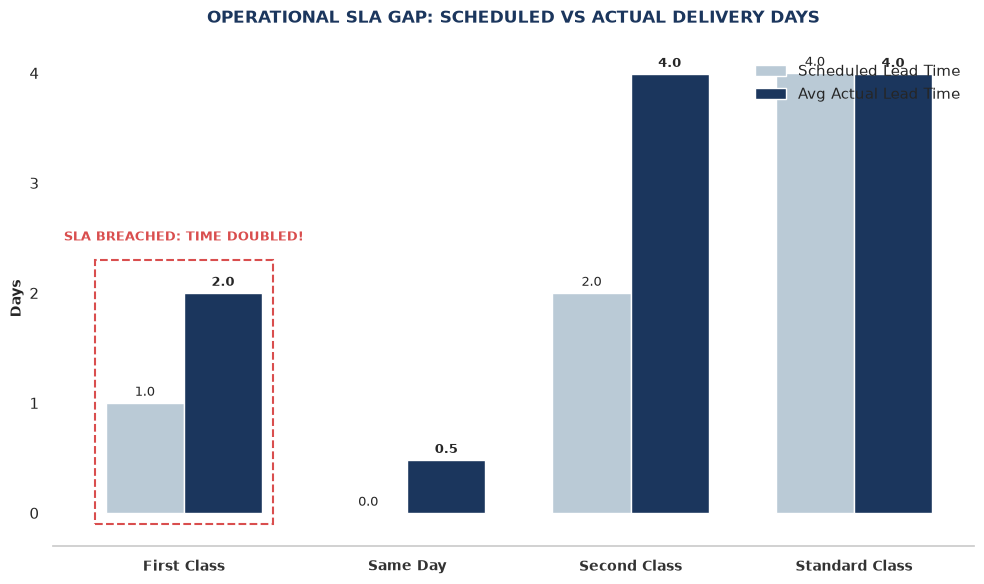

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Chuẩn bị dữ liệu từ Mục 3 (Shipping Lead Time)
data_sla = {
    "Shipping Mode": ["First Class", "Same Day", "Second Class", "Standard Class"],
    "Scheduled Time": [1, 0, 2, 4],
    "Actual Time": [2.0, 0.48, 3.99, 3.99]
}
df_sla = pd.DataFrame(data_sla)

x = np.arange(len(df_sla["Shipping Mode"]))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
fig.patch.set_facecolor("#ffffff")
ax.set_facecolor("#ffffff")

# Vẽ cặp cột cam kết và thực tế
rects1 = ax.bar(x - width/2, df_sla["Scheduled Time"], width, label="Scheduled Lead Time", color="#BACAD6")
rects2 = ax.bar(x + width/2, df_sla["Actual Time"], width, label="Avg Actual Lead Time", color="#1B365D")

# Highlight riêng khu vực First Class bằng một khung nét đứt (Pre-attentive attribute: Enclosure)
rect = plt.Rectangle((-0.4, -0.1), 0.8, 2.4, fill=False, edgecolor="#D94E4E", linestyle="--", linewidth=1.5)
ax.add_patch(rect)
ax.text(0, 2.45, "SLA BREACHED: TIME DOUBLED!", ha="center", va="bottom", color="#D94E4E", fontsize=9, fontweight="bold")

# Định dạng trục và chữ
ax.set_title("OPERATIONAL SLA GAP: SCHEDULED VS ACTUAL DELIVERY DAYS", fontsize=12, fontweight="bold", color="#1B365D", pad=20)
ax.set_xticks(x)
ax.set_xticklabels(df_sla["Shipping Mode"], fontsize=10, fontweight="bold", color="#333333")
ax.set_ylabel("Days", fontsize=10, fontweight="bold")
ax.legend(frameon=False, loc="upper right")

# Làm sạch viền
for spine in ["top", "right", "left"]: ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#cccccc")

# Thêm số liệu trên đỉnh cột
ax.bar_label(rects1, padding=3, fmt="%.1f", fontsize=9)
ax.bar_label(rects2, padding=3, fmt="%.1f", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from eda import Late_Perc_Group

# 1. Initialize data from the EDA module
df = Late_Perc_Group()[0]

# Sort by SLA (scheduled_lead_time) ascending for a clean upward line trend
df = df.sort_values("scheduled_lead_time").reset_index(drop=True)

# 2. Initialize Figure and Canvas
fig, ax1 = plt.subplots(figsize=(10, 6), dpi=100)
fig.patch.set_facecolor("#ffffff")
ax1.set_facecolor("#ffffff")

# --- COLOR PALETTE ---
COLOR_BAR = "#1B365D"   # Deep Navy Blue 
COLOR_LINE = "#D9A05B"  # Soft Amber / Muted Gold 

# Turn off gridlines
ax1.grid(False)

# 3. PLOT BARS (Left Y-Axis - Delay Rate %)
bars = ax1.bar(
    df["Shipping Mode"],
    df["Perc_Delay"] * 100,
    color=COLOR_BAR,
    alpha=0.9,
    width=0.4,
    label="Delay Rate (%)",
)

ax1.set_xlabel("Shipping Mode", fontsize=11, fontweight="bold", labelpad=12, color="#333333")
ax1.set_ylabel("Delay Rate (%)", color=COLOR_BAR, fontsize=11, fontweight="bold")
ax1.tick_params(axis="y", labelcolor=COLOR_BAR)
ax1.set_ylim(0, 110)

# Add Data Labels on top of each Bar
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 2,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontweight="bold",
        color=COLOR_BAR,
    )

# 4. PLOT LINE (Right Y-Axis - SLA Lead Time Days)
ax2 = ax1.twinx()
ax2.grid(False) # Ensure the secondary axis doesn't generate a grid

line = ax2.plot(
    df["Shipping Mode"],
    df["scheduled_lead_time"],
    color=COLOR_LINE,
    marker="o",
    linewidth=3.5,
    markersize=9,
    label="Scheduled Lead Time (Days)",
)

ax2.set_ylabel("Scheduled Lead Time (Days)", color=COLOR_LINE, fontsize=11, fontweight="bold")
ax2.tick_params(axis="y", labelcolor=COLOR_LINE)
ax2.set_ylim(-0.5, 5)

# Add Data Labels right above the Line markers
for i, txt in enumerate(df["scheduled_lead_time"]):
    ax2.annotate(
        f"{txt} Day(s)",
        (df["Shipping Mode"][i], df["scheduled_lead_time"][i]),
        textcoords="offset points",
        xytext=(0, 12),
        ha="center",
        fontweight="bold",
        color=COLOR_LINE,
    )

# 5. Title & Aesthetics Clean-up
plt.title(
    "SHIPPING PERFORMANCE ANALYSIS\nDelay Rate vs. Scheduled Lead Time (SLA)",
    fontsize=13,
    fontweight="bold",
    pad=22,
    color="#1B365D",
)

# Hide unnecessary chart borders (Spines) for an executive look
for ax in [ax1, ax2]:
    ax.spines["top"].set_visible(False)
    ax.spines["bottom"].set_color("#ffffff") # Clean base line
    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
import os
import matplotlib.pyplot as plt
import pandas as pd

# 1. Data Preparation



# 2. Initialize side-by-side subplots (1 row, 2 columns) sharing the Y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True, dpi=100)
fig.patch.set_facecolor("#ffffff")

# --- EXECUTIVE COLOR PALETTE ---
COLOR_QTY = "#4A7BB0"    # Muted Slate Blue for Order Quantity
COLOR_SALES = "#1B365D"  # Deep Navy Blue for Total Sales Volume

# --- SUBPLOT 1: TOTAL ORDER QUANTITY (Left) ---
ax1.set_facecolor("#ffffff")
ax1.grid(False)
bars1 = ax1.barh(df["Shipping Mode"], df["Order_quantity_by_mode"], color=COLOR_QTY, height=0.55)
ax1.set_title("TOTAL ORDER QUANTITY", fontsize=11, fontweight="bold", color="#555555", pad=15)

# Add Data Labels for the left subplot
for bar in bars1:
    width = bar.get_width()
    ax1.text(
        width + max(df["Order_quantity_by_mode"]) * 0.02,
        bar.get_y() + bar.get_height()/2,
        f"{int(width):,}",
        ha="left", va="center", fontsize=10, fontweight="bold", color=COLOR_QTY
    )

# --- SUBPLOT 2: TOTAL SALES VOLUME (Right) ---
ax2.set_facecolor("#ffffff")
ax2.grid(False)
bars2 = ax2.barh(df["Shipping Mode"], df["Total_sales_by_mode"], color=COLOR_SALES, height=0.55)
ax2.set_title("TOTAL SALES VOLUME ($)", fontsize=11, fontweight="bold", color="#1B365D", pad=15)

# Add Data Labels for the right subplot (Formatted in Millions of USD)
for bar in bars2:
    width = bar.get_width()
    ax2.text(
        width + max(df["Total_sales_by_mode"]) * 0.02,
        bar.get_y() + bar.get_height()/2,
        f"${width/1e6:.2f}M",
        ha="left", va="center", fontsize=10, fontweight="bold", color=COLOR_SALES
    )

# 3. Clean up axes and spines
for ax in [ax1, ax2]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_color("#cccccc")
    ax.get_xaxis().set_visible(False)  # Hide X-axis completely since data labels are visible

# Format the shared Y-axis labels
ax1.tick_params(axis="y", labelsize=11, color="#333333")
for label in ax1.get_yticklabels():
    label.set_weight("bold")

# Extend X-axis limits slightly to prevent data labels from being clipped
ax1.set_xlim(0, max(df["Order_quantity_by_mode"]) * 1.2)
ax2.set_xlim(0, max(df["Total_sales_by_mode"]) * 1.2)

# 4. Add the overarching main title
plt.suptitle(
    "ORDER INSIGHTS BY SHIPPING MODE\nSide-by-Side Distribution Analysis",
    fontsize=14, fontweight="bold", color="#1B365D", y=1.05
)

plt.tight_layout()
plt.show()

/tmp/ipykernel_16/980436684.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax2.set_xticklabels(["Actual Lead Time", "Scheduled Lead Time", "Average Delay"], fontsize=10, fontweight="bold")


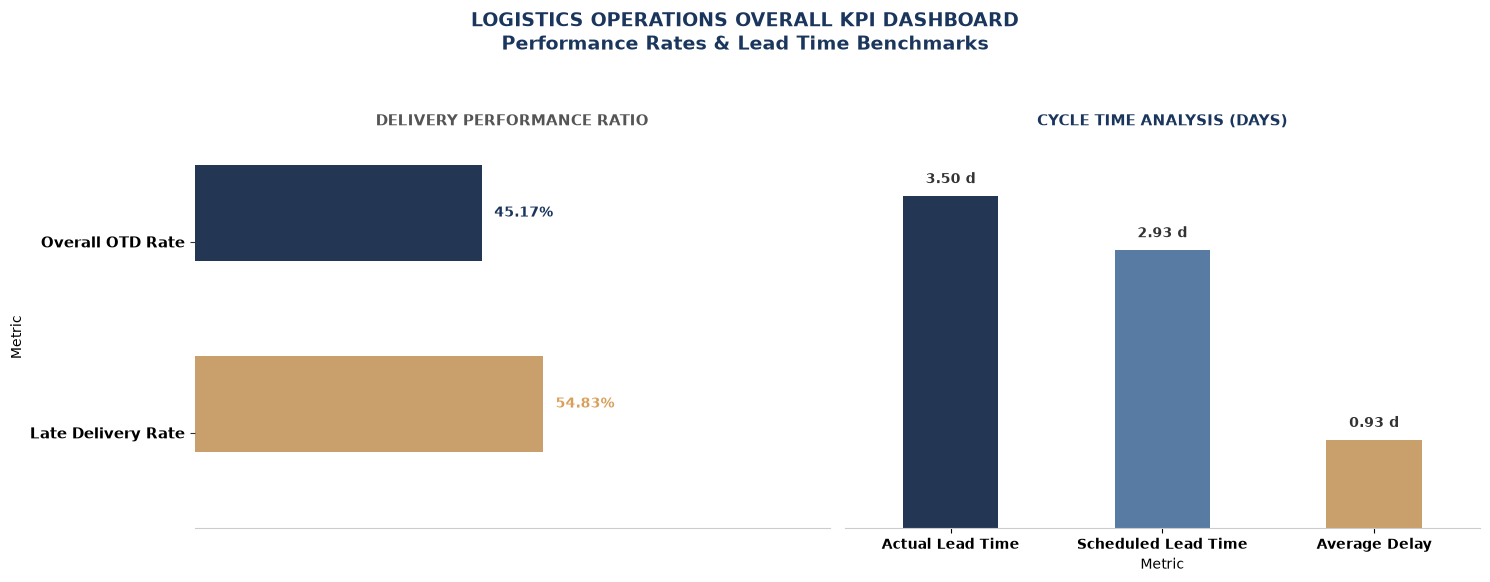

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Initialize raw data from the OVERALL KPI table
data_kpi = {
    "Metric": [
        "Overall OTD Rate", 
        "Late Delivery Rate", 
        "Average Actual Lead Time", 
        "Average Scheduled Lead Time", 
        "Average Delay Days"
    ],
    "Value": [45.17, 54.83, 3.50, 2.93, 0.93]
}
df_all = pd.DataFrame(data_kpi)

# Split the dataset into two subsets for the independent subplots
df_left = df_all.iloc[0:2].copy()   # OTD and Late Rates (%)
df_right = df_all.iloc[2:5].copy()  # Time-based metrics (Days)

# 2. Initialize dual-plot canvas (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5), dpi=100)
fig.patch.set_facecolor("#ffffff")

# --- NAVY COLOR PALETTE ---
NAVY_DARK = "#1B365D"   # Deep Navy for OTD and Actual Lead Time (Primary)
NAVY_LIGHT = "#4A7BB0"  # Light Navy/Slate for Scheduled Lead Time
AMBER_ALERT = "#D9A05B" # Amber/Sand gold for Late/Delay metrics 

# Completely disable grid lines on both subplots
ax1.grid(False)
ax2.grid(False)

# =========================================================
# 📊 LEFT SUBPLOT: COMPARING OTD VS LATE DELIVERY RATE
# =========================================================
ax1.set_facecolor("#ffffff")

# Render horizontal bar chart using Seaborn
sns.barplot(
    x="Value", 
    y="Metric", 
    data=df_left, 
    ax=ax1, 
    palette=[NAVY_DARK, AMBER_ALERT],
    hue="Metric",           
    legend=False,
    height=0.5
)

ax1.set_title("DELIVERY PERFORMANCE RATIO", fontsize=11, fontweight="bold", color="#555555", pad=15)
ax1.set_xlim(0, 100) # Percentage scale from 0 to 100

# Add Data Labels (%) directly onto the horizontal bars
for p in ax1.patches:
    width = p.get_width()
    ax1.text(
        width + 2, 
        p.get_y() + p.get_height() / 2, 
        f"{width:.2f}%", 
        ha="left", va="center", fontsize=10, fontweight="bold",
        color=NAVY_DARK if width < 50 else AMBER_ALERT
    )

# =========================================================
# 📊 RIGHT SUBPLOT: LEAD TIME DETAILS & DELAY DAYS
# =========================================================
ax2.set_facecolor("#ffffff")

# Render vertical bar chart using Seaborn
sns.barplot(
    x="Metric", 
    y="Value", 
    data=df_right, 
    ax=ax2, 
    palette=[NAVY_DARK, NAVY_LIGHT, AMBER_ALERT],
    hue="Metric",
    legend=False,
    width=0.45
)

ax2.set_title("CYCLE TIME ANALYSIS (DAYS)", fontsize=11, fontweight="bold", color=NAVY_DARK, pad=15)
# Shorten X-axis labels for a cleaner corporate presentation layout
ax2.set_xticklabels(["Actual Lead Time", "Scheduled Lead Time", "Average Delay"], fontsize=10, fontweight="bold")

# Add Data Labels (Days) on top of the vertical bars
for p in ax2.patches:
    height = p.get_height()
    if height > 0:
        ax2.text(
            p.get_x() + p.get_width() / 2., 
            height + 0.1, 
            f"{height:.2f} d", 
            ha="center", va="bottom", fontsize=10, fontweight="bold", color="#333333"
        )

# =========================================================
# 🛠️ EXECUTIVE STYLE AESTHETIC REFINEMENTS
# =========================================================
for ax in [ax1, ax2]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_color("#cccccc")
    ax.spines["left"].set_visible(False)
    ax.get_xaxis().set_visible(False) if ax == ax1 else ax.get_yaxis().set_visible(False)

# Custom formatting for the left subplot's Y-axis labels
ax1.tick_params(axis="y", labelsize=11, color="#333333")
for label in ax1.get_yticklabels():
    label.set_weight("bold")

# Expand Y-axis headroom for the right subplot to avoid data label clipping
ax2.set_ylim(0, max(df_right["Value"]) * 1.15)

# Main overarching title for the KPI Dashboard
plt.suptitle(
    "LOGISTICS OPERATIONS OVERALL KPI DASHBOARD\nPerformance Rates & Lead Time Benchmarks",
    fontsize=14, fontweight="bold", color=NAVY_DARK, y=1.05
)

plt.tight_layout()
plt.show()

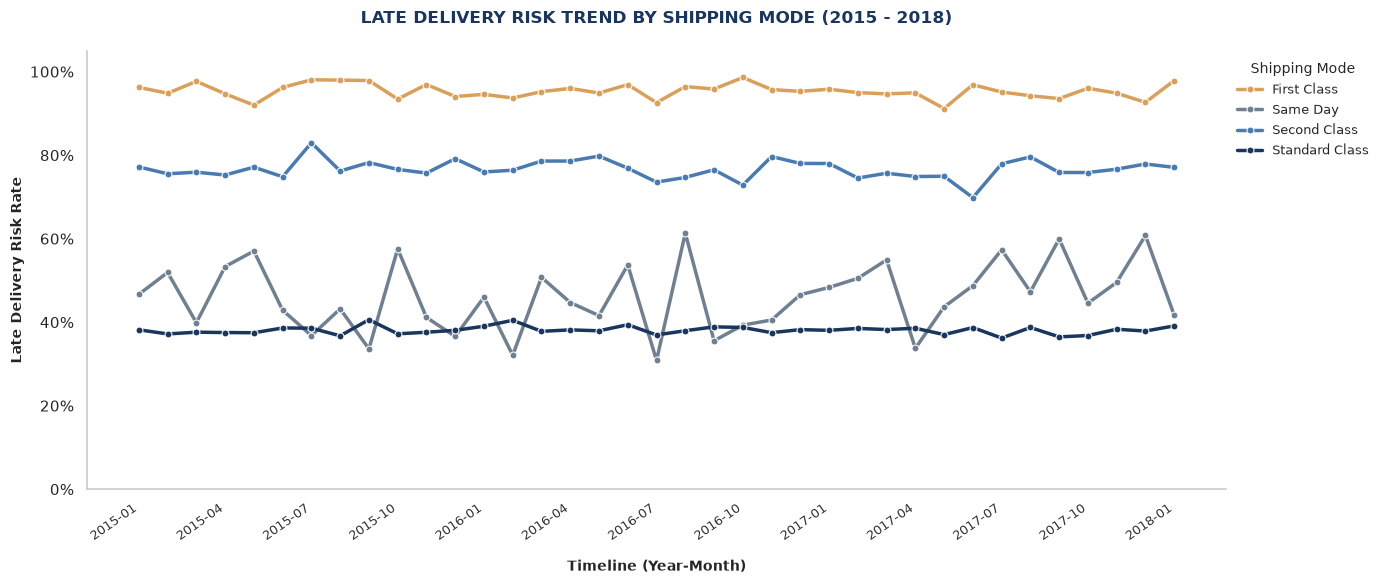

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from eda import Late_Perc_Period

df_trend = Late_Perc_Period()[0]

# 2. Khởi tạo khung tranh đơn
fig, ax = plt.subplots(figsize=(14, 6), dpi=100)
fig.patch.set_facecolor("#ffffff")
ax.set_facecolor("#ffffff")

# Tắt đường lưới
ax.grid(False)

# Bảng màu phân tách các nhóm (Tone Navy chủ đạo phối Amber cảnh báo)
PALETTE_TREND = {
    "First Class": "#D9A05B",     # Màu hổ phách (Nhóm nguy cơ cao nhất)
    "Second Class": "#4A7BB0",    # Xanh Slate
    "Standard Class": "#1B365D",  # Navy đậm quy chuẩn
    "Same Day": "#708090"         # Xám khói
}

# 3. Vẽ đường xu hướng bằng Seaborn
sns.lineplot(
    x="year_month", 
    y="Late_delivery_risk", 
    hue="Shipping Mode", 
    data=df_trend, 
    ax=ax, 
    palette=PALETTE_TREND,
    linewidth=2.5,
    marker="o",
    markersize=5
)

# 4. Cấu hình tiêu đề và nhãn các trục
COLOR_NAVY_DARK = "#1B365D"
ax.set_title("LATE DELIVERY RISK TREND BY SHIPPING MODE (2015 - 2018)", fontsize=12, fontweight="bold", color=COLOR_NAVY_DARK, pad=20)
ax.set_xlabel("Timeline (Year-Month)", fontsize=10, fontweight="bold", labelpad=12)
ax.set_ylabel("Late Delivery Risk Rate", fontsize=10, fontweight="bold")

# Định dạng trục Y hiển thị theo %
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda y, loc: f"{int(y*100)}%"))

# Hạ tỷ lệ hiển thị nhãn trục X (Cách 3 tháng hiện 1 lần) để không bị dính chữ
all_ticks = df_trend["year_month"].unique()
thinned_ticks = all_ticks[::3]
ax.set_xticks(thinned_ticks)
ax.set_xticklabels(thinned_ticks, rotation=35, ha="right", fontsize=9, color="#333333")

# 5. Tinh chỉnh hộp chú thích (Legend) nằm góc ngoài bên phải sang trọng
ax.legend(title="Shipping Mode", title_fontsize=10, fontsize=9, loc="upper left", bbox_to_anchor=(1, 1), frameon=False)

# 6. Làm sạch đường viền
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#cccccc")
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

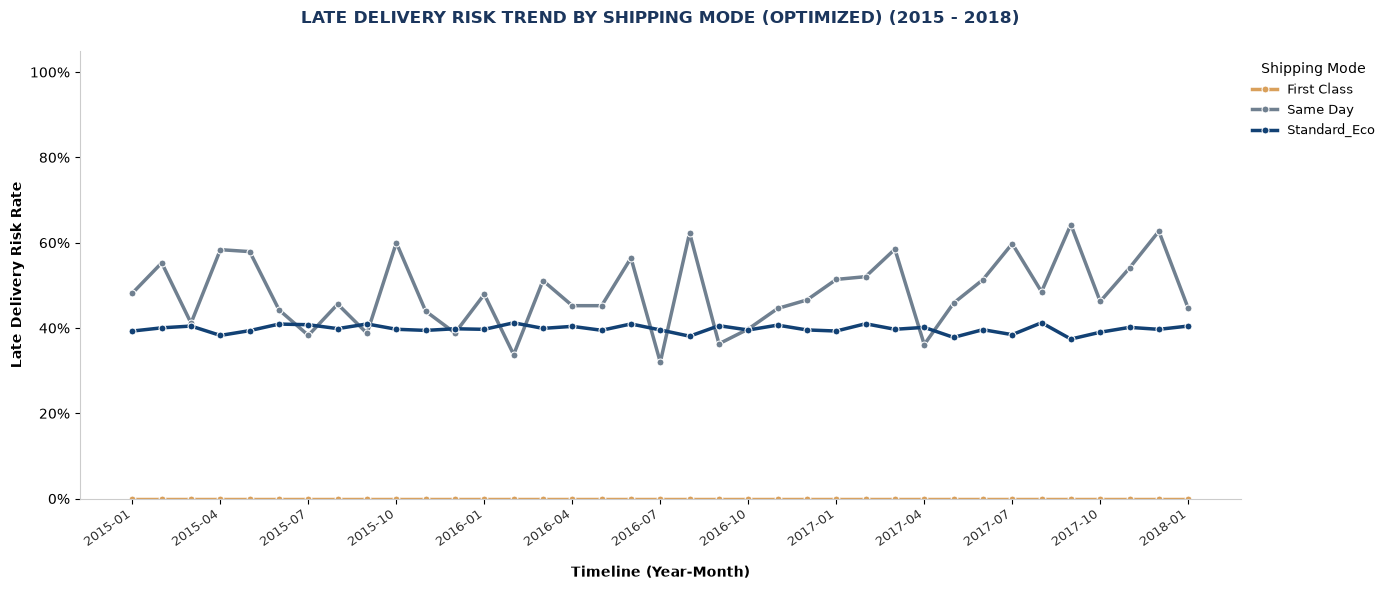

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from apply_recommendations import Late_Perc_Period_Optimized

df_trend = Late_Perc_Period_Optimized()[0]

# 2. Khởi tạo khung tranh đơn
fig, ax = plt.subplots(figsize=(14, 6), dpi=100)
fig.patch.set_facecolor("#ffffff")
ax.set_facecolor("#ffffff")

# Tắt đường lưới
ax.grid(False)

# Bảng màu phân tách các nhóm 
PALETTE_TREND = {
    "First Class": "#D9A05B",    
    "Standard_Eco": "#124174", 
    "Same Day": "#708090"     
}

# 3. Vẽ đường xu hướng bằng Seaborn
sns.lineplot(
    x="year_month", 
    y="Late_delivery_risk", 
    hue="Shipping Mode", 
    data=df_trend, 
    ax=ax, 
    palette=PALETTE_TREND,
    linewidth=2.5,
    marker="o",
    markersize=5
)

# 4. Cấu hình tiêu đề và nhãn các trục
COLOR_NAVY_DARK = "#1B365D"
ax.set_title("LATE DELIVERY RISK TREND BY SHIPPING MODE (OPTIMIZED) (2015 - 2018)", fontsize=12, fontweight="bold", color=COLOR_NAVY_DARK, pad=20)
ax.set_xlabel("Timeline (Year-Month)", fontsize=10, fontweight="bold", labelpad=12)
ax.set_ylabel("Late Delivery Risk Rate", fontsize=10, fontweight="bold")

# Định dạng trục Y hiển thị theo %
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda y, loc: f"{int(y*100)}%"))

# Hạ tỷ lệ hiển thị nhãn trục X (Cách 3 tháng hiện 1 lần) để không bị dính chữ
all_ticks = df_trend["year_month"].unique()
thinned_ticks = all_ticks[::3]
ax.set_xticks(thinned_ticks)
ax.set_xticklabels(thinned_ticks, rotation=35, ha="right", fontsize=9, color="#333333")

# 5. Tinh chỉnh hộp chú thích (Legend) nằm góc ngoài bên phải sang trọng
ax.legend(title="Shipping Mode", title_fontsize=10, fontsize=9, loc="upper left", bbox_to_anchor=(1, 1), frameon=False)

# 6. Làm sạch đường viền
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#cccccc")
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()